In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Plant_1_Generation_Data.csv")
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [5]:
df.columns

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')

In [6]:
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], dayfirst=True)

In [7]:
df['hour'] = df['DATE_TIME'].dt.hour
df['date'] = df['DATE_TIME'].dt.date
df['day'] = df['DATE_TIME'].dt.day

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  object        
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
 7   hour         68778 non-null  int32         
 8   date         68778 non-null  object        
 9   day          68778 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(2), int64(1), object(2)
memory usage: 4.7+ MB


DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
hour           0
date           0
day            0
dtype: int64

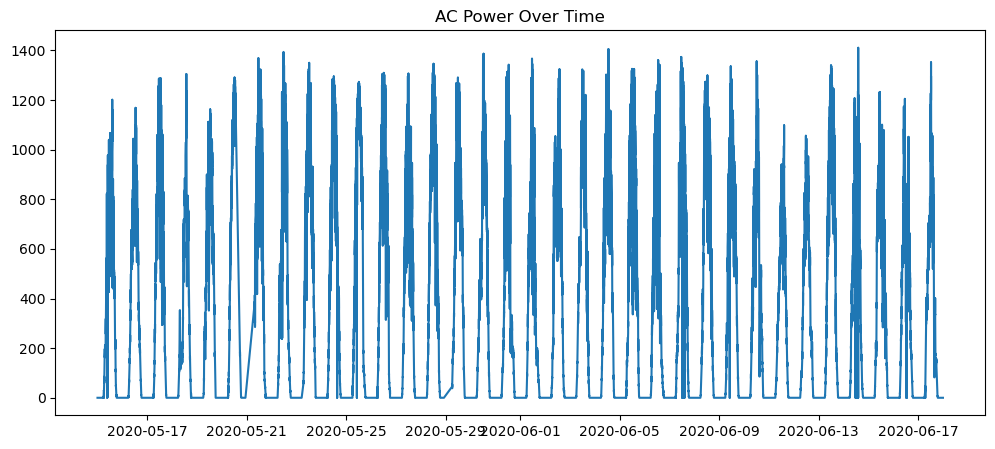

In [9]:

plt.figure(figsize=(12,5))
plt.plot(df['DATE_TIME'], df['AC_POWER'])
plt.title("AC Power Over Time")
plt.show()

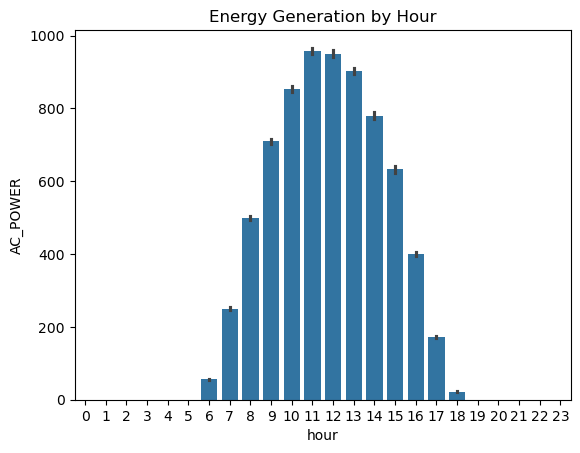

In [10]:
sns.barplot(x='hour', y='AC_POWER', data=df)
plt.title("Energy Generation by Hour")
plt.show()

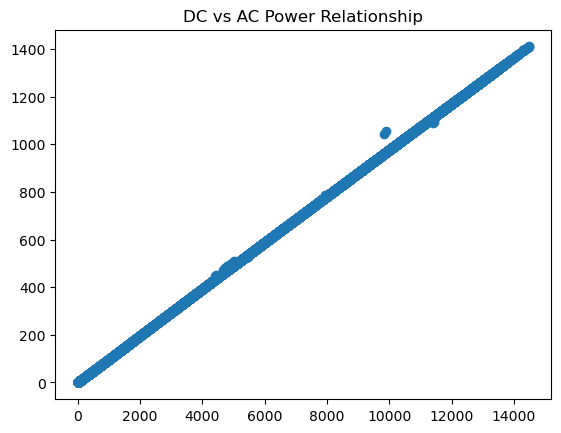

In [11]:
plt.scatter(df['DC_POWER'], df['AC_POWER'])
plt.title("DC vs AC Power Relationship")
plt.show()

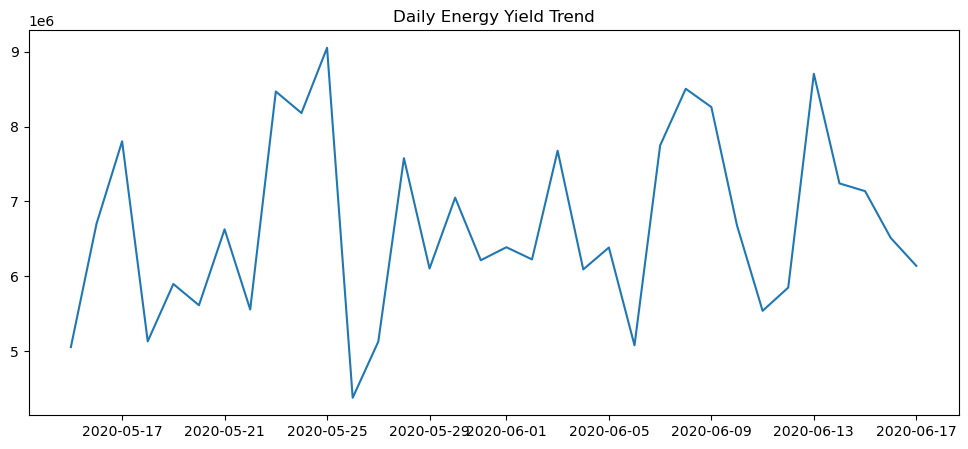

In [12]:
daily = df.groupby('date')['DAILY_YIELD'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily)
plt.title("Daily Energy Yield Trend")
plt.show()

<Axes: xlabel='SOURCE_KEY'>

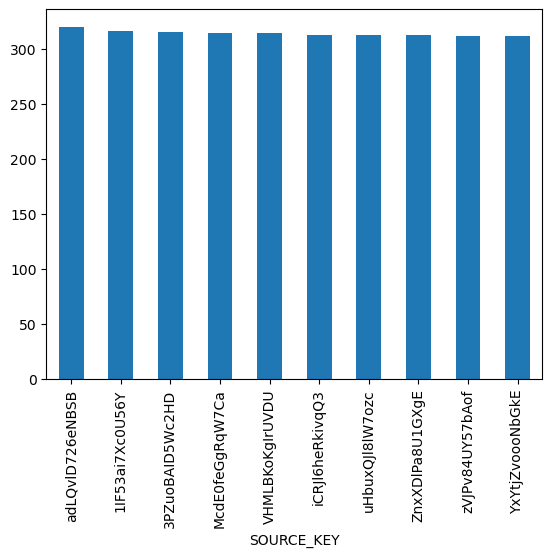

In [13]:
top_sources = df.groupby('SOURCE_KEY')['AC_POWER'].mean().sort_values(ascending=False).head(10)
top_sources.plot(kind='bar')

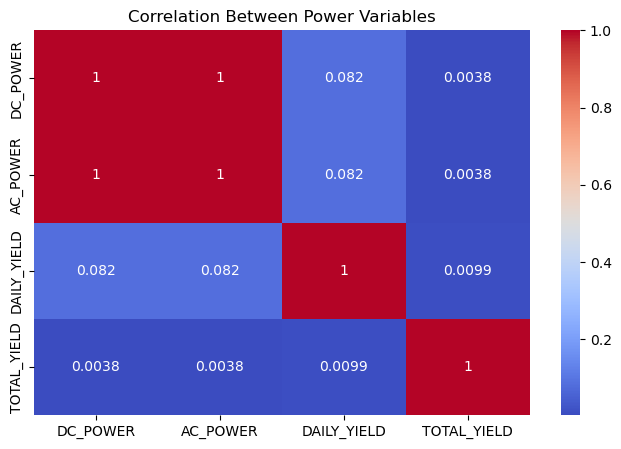

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['DC_POWER','AC_POWER','DAILY_YIELD','TOTAL_YIELD']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Between Power Variables")
plt.show()

In [15]:
df['efficiency'] = df['AC_POWER'] / (df['DC_POWER'] + 1)

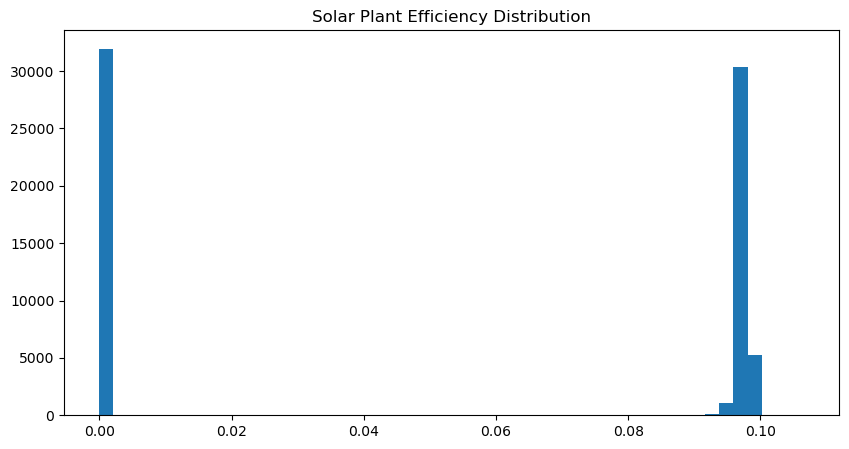

In [16]:
plt.figure(figsize=(10,5))
plt.hist(df['efficiency'], bins=50)
plt.title("Solar Plant Efficiency Distribution")
plt.show()

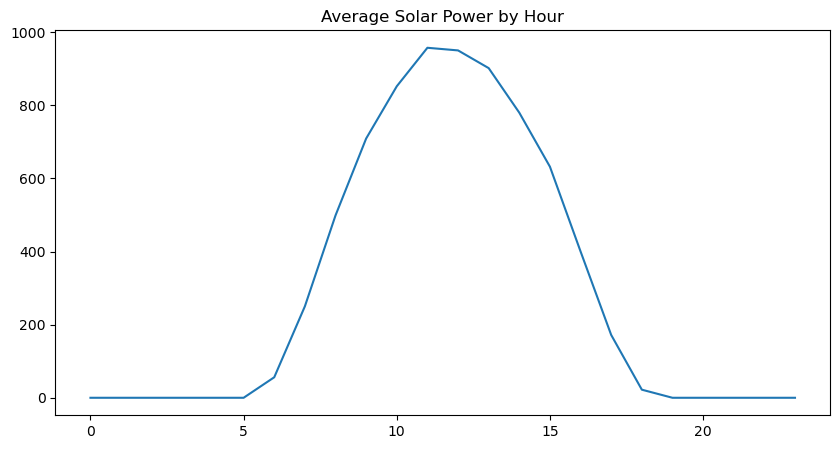

In [17]:
hourly = df.groupby('hour')['AC_POWER'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly)
plt.title("Average Solar Power by Hour")
plt.show()

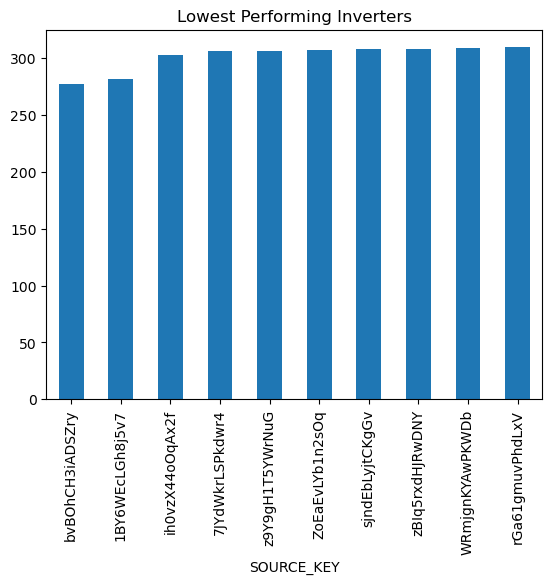

In [18]:
inverter_perf = df.groupby('SOURCE_KEY')['AC_POWER'].mean().sort_values()

inverter_perf.head(10).plot(kind='bar')
plt.title("Lowest Performing Inverters")
plt.show()

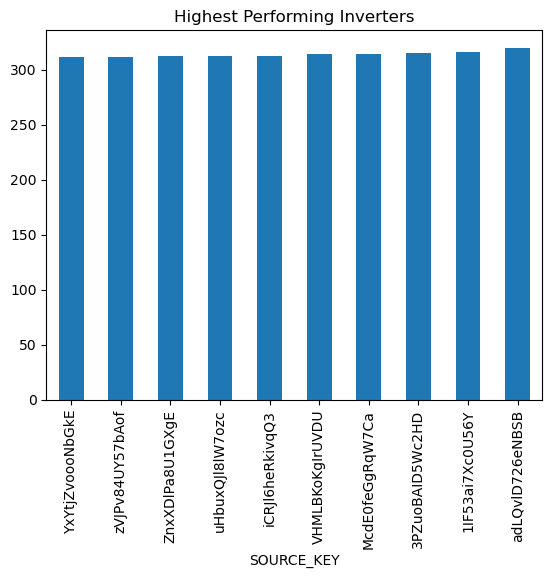

In [19]:
inverter_perf.tail(10).plot(kind='bar')
plt.title("Highest Performing Inverters")
plt.show()

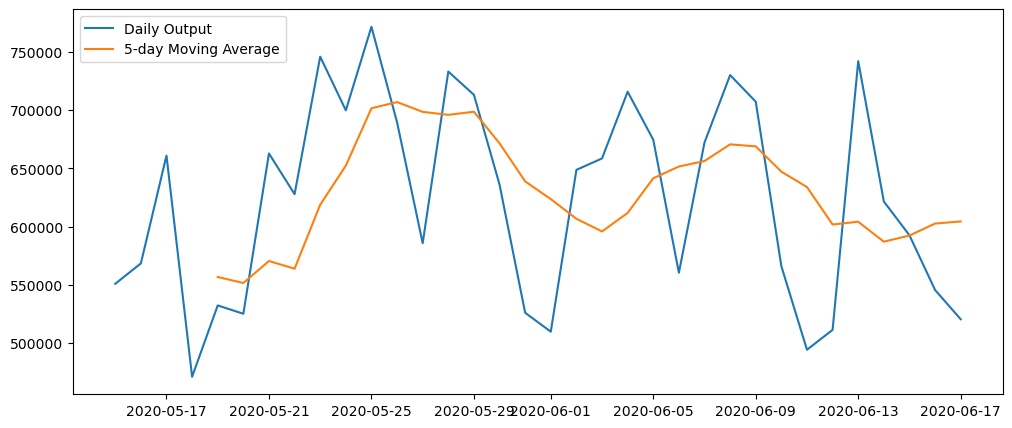

In [21]:
daily = df.groupby('date')['AC_POWER'].sum()

rolling_avg = daily.rolling(window=5).mean()

plt.figure(figsize=(12,5))
plt.plot(daily, label="Daily Output")
plt.plot(rolling_avg, label="5-day Moving Average")
plt.legend()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

features = ['DC_POWER', 'hour']
X = df[features]
y = df['AC_POWER']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9999986624869543


In [23]:
Q1 = df['AC_POWER'].quantile(0.25)
Q3 = df['AC_POWER'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['AC_POWER'] < lower_bound) | (df['AC_POWER'] > upper_bound)]

print("Outliers detected:", len(outliers))

Outliers detected: 0


<Axes: ylabel='count'>

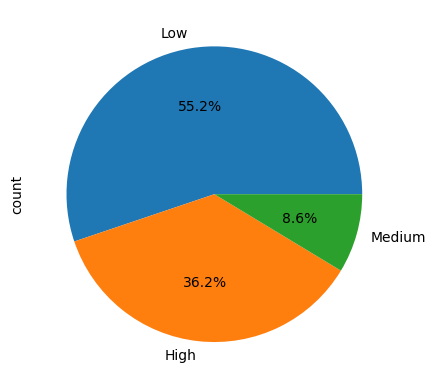

In [24]:
df['power_level'] = pd.cut(df['AC_POWER'],
                           bins=[-1, 50, 200, 1000],
                           labels=['Low', 'Medium', 'High'])

df['power_level'].value_counts().plot(kind='pie', autopct='%1.1f%%')

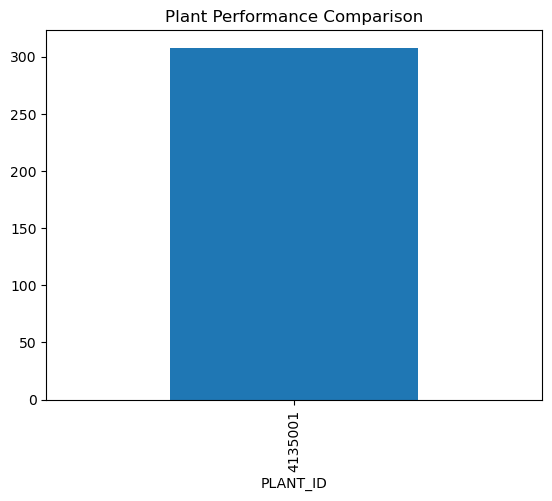

In [25]:
plant_summary = df.groupby('PLANT_ID')['AC_POWER'].mean()

plant_summary.plot(kind='bar')
plt.title("Plant Performance Comparison")
plt.show()

In [26]:
peak_hour = df.groupby('hour')['AC_POWER'].mean().idxmax()

print("Peak solar generation hour:", peak_hour)

Peak solar generation hour: 11


In [27]:
total_energy = df['DAILY_YIELD'].sum()
avg_efficiency = df['AC_POWER'].mean() / df['DC_POWER'].mean()

print("Total Energy Generated:", total_energy)
print("Average Efficiency:", avg_efficiency)

Total Energy Generated: 226690137.8059445
Average Efficiency: 0.09779506543078857


In [28]:
corr = df[['DC_POWER','AC_POWER','DAILY_YIELD','TOTAL_YIELD']].corr()
print(corr)

             DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD
DC_POWER     1.000000  0.999996     0.082284     0.003815
AC_POWER     0.999996  1.000000     0.082234     0.003804
DAILY_YIELD  0.082284  0.082234     1.000000     0.009867
TOTAL_YIELD  0.003815  0.003804     0.009867     1.000000


In [29]:
df.set_index('DATE_TIME', inplace=True)

hourly_data = df['AC_POWER'].resample('H').mean()

C:\Users\user\AppData\Local\Temp\ipykernel_14264\416948350.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = df['AC_POWER'].resample('H').mean()


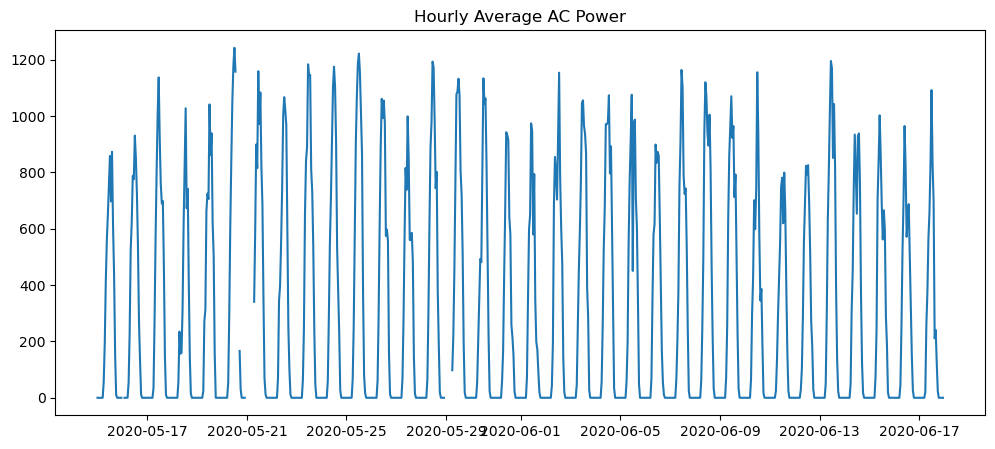

In [30]:
plt.figure(figsize=(12,5))
plt.plot(hourly_data)
plt.title("Hourly Average AC Power")
plt.show()

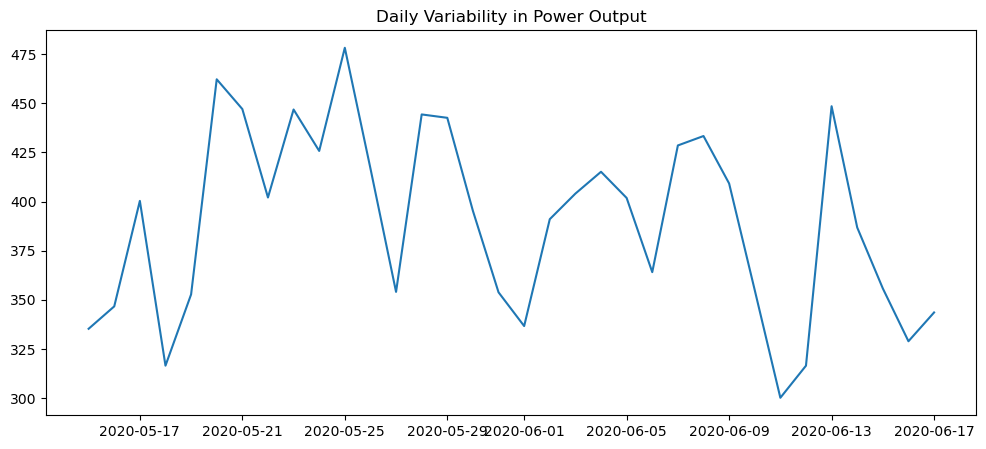

In [31]:
daily_std = df['AC_POWER'].resample('D').std()

plt.figure(figsize=(12,5))
plt.plot(daily_std)
plt.title("Daily Variability in Power Output")
plt.show()

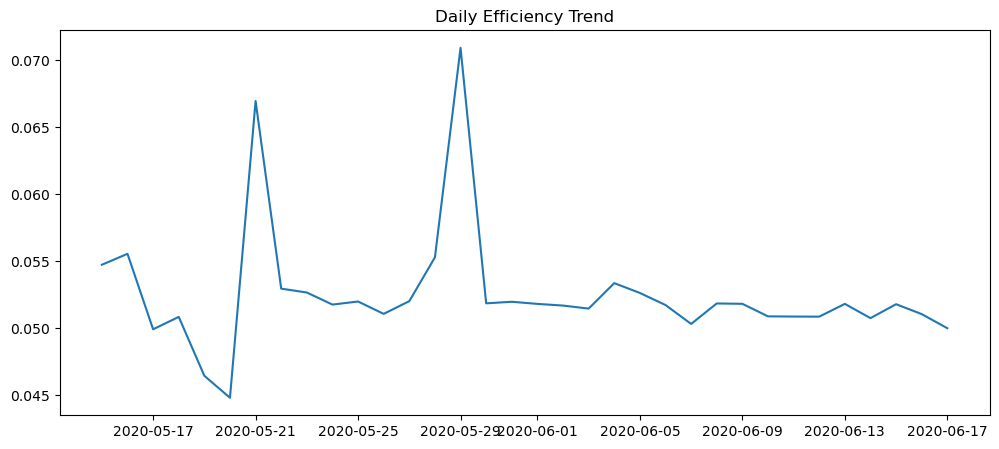

In [32]:
df['efficiency'] = df['AC_POWER'] / (df['DC_POWER'] + 1)

eff_daily = df['efficiency'].resample('D').mean()

plt.figure(figsize=(12,5))
plt.plot(eff_daily)
plt.title("Daily Efficiency Trend")
plt.show()

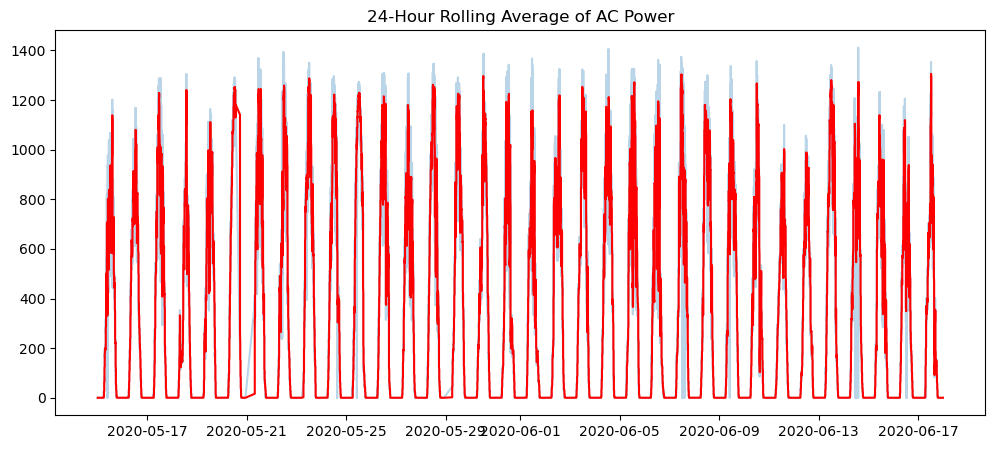

In [33]:
rolling_mean = df['AC_POWER'].rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(df['AC_POWER'], alpha=0.3)
plt.plot(rolling_mean, color='red')
plt.title("24-Hour Rolling Average of AC Power")
plt.show()

In [34]:
peak_time = df.groupby(df.index.hour)['AC_POWER'].mean().idxmax()

print("Peak energy generation hour:", peak_time)

Peak energy generation hour: 11


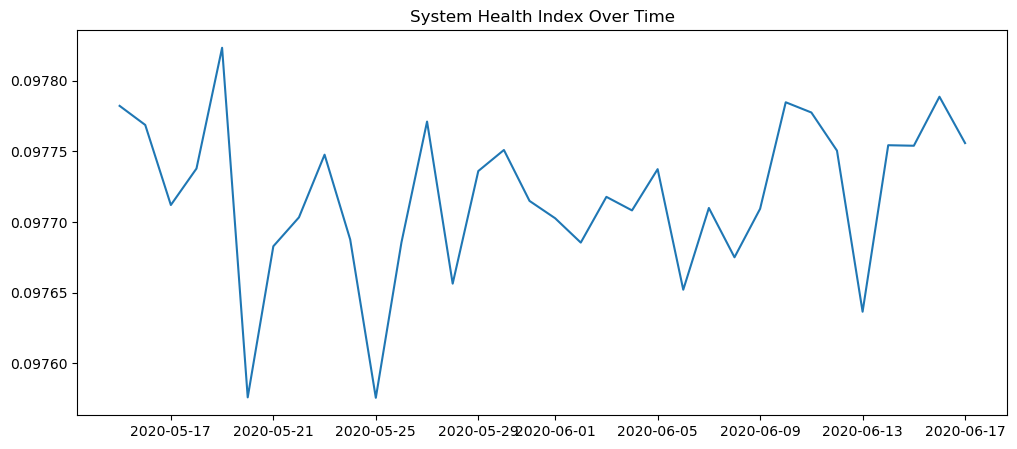

In [35]:
df['health_index'] = df['AC_POWER'] / df['DC_POWER'].replace(0, np.nan)

health_trend = df['health_index'].resample('D').mean()

plt.figure(figsize=(12,5))
plt.plot(health_trend)
plt.title("System Health Index Over Time")
plt.show()